In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
#import bayesfm as bfm
import statsmodels.api as sm
from matplotlib.pyplot import plot_date

In [4]:
EBC = pd.read_csv("ebc_weigths.csv", index_col=0, parse_dates=True)
EBC_numeric = EBC.apply(pd.to_numeric, errors="coerce")
EBC_numeric

,A,A.1,AAF,AAL,AAL.1,AAP,AAPL,AAV,ABA,ABBV,...,YHOO,YUM,ZA,ZB,ZBH,ZBRA,ZE,ZION,ZRN,ZTS
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,0.001002,0.000000,0.0,0.001041,0.0,0.0,0.000000,0.0,0.002034,0.000000,...,0.0,0.000000,0.001633,0.001978,0.000000,0.000000,0.001902,0.0,0.0,0.000000
1967-02-28,0.001010,0.000000,0.0,0.001107,0.0,0.0,0.000000,0.0,0.001835,0.000000,...,0.0,0.000000,0.001137,0.002339,0.000000,0.000000,0.001531,0.0,0.0,0.000000
1967-03-31,0.000977,0.000000,0.0,0.001094,0.0,0.0,0.000000,0.0,0.001831,0.000000,...,0.0,0.000000,0.001183,0.002301,0.000000,0.000000,0.001581,0.0,0.0,0.000000
1967-04-30,0.001073,0.000000,0.0,0.001091,0.0,0.0,0.000000,0.0,0.001602,0.000000,...,0.0,0.000000,0.001270,0.002080,0.000000,0.000000,0.001695,0.0,0.0,0.000000
1967-05-31,0.001065,0.000000,0.0,0.001124,0.0,0.0,0.000000,0.0,0.001559,0.000000,...,0.0,0.000000,0.001312,0.001902,0.000000,0.000000,0.001555,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,0.000000,0.001612,0.0,0.001466,0.0,0.0,0.001720,0.0,0.000000,0.003488,...,0.0,0.002517,0.000000,0.000000,0.002524,0.001179,0.000000,0.0,0.0,0.001876
2024-09-30,0.000000,0.001674,0.0,0.001483,0.0,0.0,0.001680,0.0,0.000000,0.003865,...,0.0,0.002578,0.000000,0.000000,0.002521,0.001247,0.000000,0.0,0.0,0.001933
2024-10-31,0.000000,0.001701,0.0,0.000000,0.0,0.0,0.001715,0.0,0.000000,0.003699,...,0.0,0.002607,0.000000,0.000000,0.002493,0.001204,0.000000,0.0,0.0,0.001867


In [11]:
ff_df = pd.read_csv("F-F_Research_Data_5_Factors_2x3.csv", index_col=0, skiprows=3)
ff_df = ff_df[ff_df.index.astype(str).str.match(r"^\d{6}$")]
ff_df.index = pd.to_datetime(ff_df.index.astype(str), format="%Y%m")


ff_df.index = ff_df.index + pd.offsets.MonthEnd(0)
ff_df = ff_df.apply(pd.to_numeric, errors='coerce') / 100
ff_df = ff_df.loc[(ff_df.index >= '1967-01-01') & (ff_df.index < '2025-01-01')]
ff_df.rename(columns={"RF": "RiskFreeRate"}, inplace=True)
ff_df

,Mkt-RF,SMB,HML,RMW,CMA,RiskFreeRate
1967-01-31,0.0815,0.0898,0.0236,0.0129,-0.0306,0.0043
1967-02-28,0.0077,0.0301,-0.0226,0.0166,-0.0093,0.0036
1967-03-31,0.0400,0.0177,0.0047,0.0082,-0.0150,0.0039
1967-04-30,0.0389,0.0043,-0.0229,0.0309,-0.0372,0.0032
1967-05-31,-0.0432,0.0245,0.0080,-0.0119,0.0162,0.0033
...,...,...,...,...,...,...
2024-08-31,0.0161,-0.0356,-0.0110,0.0073,0.0082,0.0048
2024-09-30,0.0173,-0.0091,-0.0277,0.0018,-0.0029,0.0040
2024-10-31,-0.0100,-0.0088,0.0086,-0.0140,0.0098,0.0039
2024-11-30,0.0649,0.0462,0.0015,-0.0231,-0.0205,0.0040


In [69]:
mom = pd.read_csv("F-F_Momentum_Factor.csv", index_col=0, skiprows=15)
mom = mom[mom.index.astype(str).str.match(r"^\d{6}$")]
mom.index = pd.to_datetime(mom.index.astype(str), format="%Y%m")


mom.index = mom.index + pd.offsets.MonthEnd(0)
mom = mom.apply(pd.to_numeric, errors='coerce') / 100
mom = mom.loc[(mom.index >= '1967-01-01') & (mom.index < '2025-01-01')]
mom

,-1.50
192702,
1967-01-31,-0.0700
1967-02-28,0.0351
1967-03-31,0.0139
1967-04-30,0.0052
1967-05-31,0.0066
...,...
2024-08-31,0.0477
2024-09-30,-0.0059
2024-10-31,0.0298


In [70]:
cap_data = pd.read_csv("sp500_market_caps.csv", index_col="date")
cap_data.head()
cap_data = cap_data * 1000
cap_data_numeric = cap_data.apply(pd.to_numeric, errors='coerce')
cap_data_numeric = cap_data_numeric.fillna(0)
weight_data = cap_data_numeric.div(cap_data_numeric.sum(axis=1), axis=0)
row_sums = weight_data.sum(axis=1)
print(row_sums.head())
weight_data

date
1960-01-29    1.0
1960-02-29    1.0
1960-03-31    1.0
1960-04-29    1.0
1960-05-31    1.0
dtype: float64


,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1960-01-29,0.000291,0.000336,0.000111,0.0,0.001253,0.000000,0.000000,0.0,0.001330,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1960-02-29,0.000297,0.000339,0.000110,0.0,0.001204,0.000000,0.000000,0.0,0.001387,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1960-03-31,0.000284,0.000305,0.000107,0.0,0.001269,0.000000,0.000000,0.0,0.001384,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1960-04-29,0.000265,0.000293,0.000109,0.0,0.001226,0.000000,0.000000,0.0,0.001422,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1960-05-31,0.000267,0.000277,0.000101,0.0,0.001217,0.000000,0.000000,0.0,0.001444,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-30,0.000000,0.000000,0.000000,0.0,0.000000,0.007886,0.062798,0.0,0.000000,0.000478,...,0.0,0.015402,0.000787,0.000370,0.001188,0.0,0.000191,0.0,0.000435,0.013853
2024-09-30,0.000000,0.000000,0.000000,0.0,0.000000,0.009342,0.063290,0.0,0.000000,0.000479,...,0.0,0.015940,0.000750,0.000368,0.001175,0.0,0.000189,0.0,0.000424,0.016600
2024-10-31,0.000000,0.000000,0.000000,0.0,0.000000,0.009296,0.060384,0.0,0.000000,0.000488,...,0.0,0.015848,0.000775,0.000352,0.001204,0.0,0.000199,0.0,0.000447,0.016030


In [71]:
weight_data.index = pd.to_datetime(weight_data.index, errors="coerce")
EBC.index = pd.to_datetime(EBC.index, errors="coerce")

# Align on intersection of indexes
common_index = weight_data.index.intersection(EBC.index)

weight_data_aligned = weight_data.loc[common_index]
EBC_aligned = EBC.loc[common_index]

# Align columns on intersection too
common_cols = weight_data_aligned.columns.intersection(EBC_aligned.columns)

weight_data_aligned = weight_data_aligned[common_cols]
EBC_aligned = EBC_aligned[common_cols]

In [72]:
print(common_index)

DatetimeIndex(['1967-01-31', '1967-02-28', '1967-03-31', '1967-05-31',
               '1967-06-30', '1967-07-31', '1967-08-31', '1967-10-31',
               '1967-11-30', '1968-01-31',
               ...
               '2023-10-31', '2023-11-30', '2024-01-31', '2024-02-29',
               '2024-04-30', '2024-05-31', '2024-07-31', '2024-09-30',
               '2024-10-31', '2024-12-31'],
              dtype='datetime64[ns]', name='date', length=486, freq=None)


In [73]:
SPC_EBC_weights = weight_data_aligned - EBC_aligned
SPC_EBC_weights

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,-0.000878,-0.001150,-0.001293,0.0,-0.000639,0.000000,0.000000,0.0,-0.001869,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1967-02-28,-0.000909,-0.001091,-0.001281,0.0,-0.000657,0.000000,0.000000,0.0,-0.004373,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1967-03-31,-0.000876,-0.001053,-0.001228,0.0,-0.000581,0.000000,0.000000,0.0,-0.004281,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1967-05-31,-0.000684,-0.001168,-0.001260,0.0,-0.000569,0.000000,0.000000,0.0,-0.003215,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1967-06-30,-0.000759,-0.001278,-0.001266,0.0,-0.000524,0.000000,0.000000,0.0,-0.002525,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-31,0.000000,0.000000,0.000000,0.0,0.000000,0.005526,0.065220,0.0,0.000000,-0.000723,...,0.0,0.011928,-0.001406,-0.002905,-0.000760,0.0,-0.000783,0.0,-0.003167,0.011241
2024-07-31,0.000000,0.000000,0.000000,0.0,0.000000,0.006451,0.062444,0.0,0.000000,-0.000802,...,0.0,0.013960,-0.001414,-0.003182,-0.001037,0.0,-0.000895,0.0,-0.003411,0.014254
2024-09-30,0.000000,0.000000,0.000000,0.0,0.000000,0.007859,0.061348,0.0,0.000000,-0.000855,...,0.0,0.014449,-0.001558,-0.003759,-0.000775,0.0,-0.000936,0.0,-0.003488,0.015569


In [74]:
# long-only (positive weights)
long_only = SPC_EBC_weights.clip(lower=0)

# short-only (negative weights, keep as negative)
short_only = -SPC_EBC_weights.clip(upper=0)

long_only


,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1967-02-28,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1967-03-31,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1967-05-31,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1967-06-30,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-31,0.0,0.0,0.0,0.0,0.0,0.005526,0.065220,0.0,0.0,0.0,...,0.0,0.011928,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011241
2024-07-31,0.0,0.0,0.0,0.0,0.0,0.006451,0.062444,0.0,0.0,0.0,...,0.0,0.013960,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.014254
2024-09-30,0.0,0.0,0.0,0.0,0.0,0.007859,0.061348,0.0,0.0,0.0,...,0.0,0.014449,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.015569


In [75]:
short_only

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,0.000878,0.001150,0.001293,-0.0,0.000639,-0.0,-0.0,-0.0,0.001869,-0.000000,...,-0.0,-0.0,-0.000000,-0.000000,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0
1967-02-28,0.000909,0.001091,0.001281,-0.0,0.000657,-0.0,-0.0,-0.0,0.004373,-0.000000,...,-0.0,-0.0,-0.000000,-0.000000,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0
1967-03-31,0.000876,0.001053,0.001228,-0.0,0.000581,-0.0,-0.0,-0.0,0.004281,-0.000000,...,-0.0,-0.0,-0.000000,-0.000000,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0
1967-05-31,0.000684,0.001168,0.001260,-0.0,0.000569,-0.0,-0.0,-0.0,0.003215,-0.000000,...,-0.0,-0.0,-0.000000,-0.000000,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0
1967-06-30,0.000759,0.001278,0.001266,-0.0,0.000524,-0.0,-0.0,-0.0,0.002525,-0.000000,...,-0.0,-0.0,-0.000000,-0.000000,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-31,-0.000000,-0.000000,-0.000000,-0.0,-0.000000,-0.0,-0.0,-0.0,-0.000000,0.000723,...,-0.0,-0.0,0.001406,0.002905,0.000760,-0.0,0.000783,-0.0,0.003167,-0.0
2024-07-31,-0.000000,-0.000000,-0.000000,-0.0,-0.000000,-0.0,-0.0,-0.0,-0.000000,0.000802,...,-0.0,-0.0,0.001414,0.003182,0.001037,-0.0,0.000895,-0.0,0.003411,-0.0
2024-09-30,-0.000000,-0.000000,-0.000000,-0.0,-0.000000,-0.0,-0.0,-0.0,-0.000000,0.000855,...,-0.0,-0.0,0.001558,0.003759,0.000775,-0.0,0.000936,-0.0,0.003488,-0.0


In [76]:
print(weight_data_aligned.shape, long_only.shape)
print(weight_data_aligned.index.equals(long_only.index))
print(weight_data_aligned.columns.equals(long_only.columns))

(486, 1596) (486, 1596)
True
True


In [77]:
long_portfolio = long_only
short_portfolio = short_only


In [78]:
long_portfolio = long_portfolio.div(long_portfolio.sum(axis=1), axis=0)

In [79]:
short_portfolio = short_portfolio.div(short_portfolio.sum(axis=1), axis=0)

In [80]:
return_data = pd.read_csv("sp500_returns_with_tickers.csv", index_col=0, parse_dates=True)
return_data

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1960-01-29,0.005155,-0.015000,-0.020785,NaN,-0.092262,NaN,NaN,NaN,-0.020833,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-02-29,0.046154,0.017767,0.009434,NaN,-0.021312,NaN,NaN,NaN,0.053192,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-03-31,-0.059553,-0.100249,-0.047170,NaN,0.038851,NaN,NaN,NaN,-0.005387,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-04-29,-0.081794,-0.056180,0.000000,NaN,-0.050407,NaN,NaN,NaN,0.010274,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-05-31,0.048851,-0.029762,-0.034654,NaN,0.029110,NaN,NaN,NaN,0.044068,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-30,NaN,NaN,NaN,NaN,NaN,0.013195,-0.001100,NaN,NaN,-0.071535,...,NaN,0.013319,0.042292,-0.310823,0.321675,NaN,0.005460,NaN,0.122718,-0.077391
2024-09-30,NaN,NaN,NaN,NaN,NaN,0.206030,0.031548,NaN,NaN,0.038948,...,NaN,0.062707,-0.016385,0.019284,0.010950,NaN,0.015013,NaN,-0.002580,0.221942
2024-10-31,NaN,NaN,NaN,NaN,NaN,-0.012676,-0.055659,NaN,NaN,0.008538,...,NaN,-0.015826,0.025228,-0.046589,0.014313,NaN,0.041981,NaN,0.042466,-0.045025


In [81]:
common_idx = return_data.index.intersection(long_portfolio.index).intersection(short_portfolio.index)
common_cols = return_data.columns.intersection(long_portfolio.columns).intersection(short_portfolio.columns)

# Step 2: align all three
returns_aligned = return_data.loc[common_idx, common_cols]
long_aligned = long_portfolio.loc[common_idx, common_cols]
short_aligned = short_portfolio.loc[common_idx, common_cols]

long_aligned


,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1967-02-28,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1967-03-31,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1967-05-31,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1967-06-30,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-31,0.0,0.0,0.0,0.0,0.0,0.010533,0.124307,0.0,0.0,0.0,...,0.0,0.022734,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.021424
2024-07-31,0.0,0.0,0.0,0.0,0.0,0.012575,0.121720,0.0,0.0,0.0,...,0.0,0.027212,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.027786
2024-09-30,0.0,0.0,0.0,0.0,0.0,0.015461,0.120690,0.0,0.0,0.0,...,0.0,0.028425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.030628


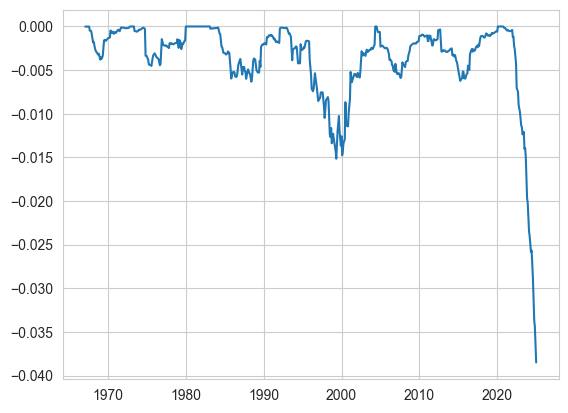

In [82]:
sum_spc_ebc_weights = SPC_EBC_weights.sum(axis=1)
plt.plot(sum_spc_ebc_weights)

In [83]:

returns_aligned = returns_aligned.fillna(0)
long_returns = (returns_aligned * long_aligned).sum(axis=1)
short_returns = (returns_aligned * short_aligned).sum(axis=1)
SPC_EBC_returns = (returns_aligned * SPC_EBC_weights).sum(axis=1)


In [84]:
import pandas as pd

EBC_returns = pd.read_csv(
    "equal_beta_portfolio_return.csv",
    index_col=0,
    parse_dates=True
)

# shift index to the last calendar day of each month
EBC_returns.index = EBC_returns.index + pd.offsets.MonthEnd(0)

EBC_returns.head()


,0
date,
1967-01-31,0.105809
1967-02-28,0.007303
1967-03-31,0.043577
1967-04-30,0.032736
1967-05-31,-0.027935


In [86]:
portfolio_returns = (pd.concat(
    [SPC_EBC_returns, ff_df["SMB"], ff_df["HML"], ff_df["RMW"], ff_df["CMA"], mom], axis=1
).set_axis(["SPC_EBC_returns", "SMB", "HML", "RMW", "CMA", "MOM"], axis=1).dropna(how= "any"))

portfolio_returns

,SPC_EBC_returns,SMB,HML,RMW,CMA,MOM
1967-01-31,-0.022398,0.0898,0.0236,0.0129,-0.0306,-0.0700
1967-02-28,0.002737,0.0301,-0.0226,0.0166,-0.0093,0.0351
1967-03-31,0.000428,0.0177,0.0047,0.0082,-0.0150,0.0139
1967-05-31,-0.016679,0.0245,0.0080,-0.0119,0.0162,0.0066
1967-06-30,-0.005071,0.0642,0.0080,-0.0084,-0.0249,0.0601
...,...,...,...,...,...,...
2024-05-31,0.035182,0.0068,-0.0136,0.0335,-0.0285,-0.0018
2024-07-31,-0.029358,0.0835,0.0562,0.0027,0.0028,-0.0236
2024-09-30,0.007259,-0.0091,-0.0277,0.0018,-0.0029,-0.0059
2024-10-31,0.011377,-0.0088,0.0086,-0.0140,0.0098,0.0298


In [87]:
portfolio_returns.tail(100)

,SPC_EBC_returns,SMB,HML,RMW,CMA,MOM
2013-02-28,-0.006419,-0.0025,0.0021,-0.0059,0.0061,0.0123
2013-04-30,-0.001950,-0.0224,0.0044,0.0039,0.0043,0.0022
2013-05-31,0.021079,0.0204,0.0267,-0.0200,-0.0095,-0.0201
2013-07-31,0.002298,0.0175,0.0058,-0.0135,0.0057,0.0174
2013-09-30,0.001347,0.0265,-0.0118,-0.0054,-0.0132,0.0302
...,...,...,...,...,...,...
2024-05-31,0.035182,0.0068,-0.0136,0.0335,-0.0285,-0.0018
2024-07-31,-0.029358,0.0835,0.0562,0.0027,0.0028,-0.0236
2024-09-30,0.007259,-0.0091,-0.0277,0.0018,-0.0029,-0.0059
2024-10-31,0.011377,-0.0088,0.0086,-0.0140,0.0098,0.0298


In [88]:
sp_returns = pd.read_csv("sp500_capweighted_returns.csv", index_col=0, parse_dates=True)

In [89]:
common_idx = return_data.index.intersection(long_portfolio.index).intersection(short_portfolio.index).intersection(sp_returns.index)
common_cols = return_data.columns.intersection(long_portfolio.columns).intersection(short_portfolio.columns)

In [90]:
returns_aligned = returns_aligned.drop(columns=["SMB", "CMA"], errors="ignore")


In [91]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from tqdm import tqdm

def run_fmb_multi(sp500, factor_returns, ROLLING_WINDOW=36, MIN_OBS=10):
    """2 pass multi factor Fama-MacBeth"""

    asset_cols = sp500.columns
    combined = sp500.join(factor_returns, how="inner")

    # Prepare betas containers as float from the start
    betas_dict = {
        f: pd.DataFrame(index=pd.Index([], name="date"), columns=asset_cols, dtype=float)
        for f in factor_returns.columns
    }
    beta_dates = []

    # ---------- First pass: rolling time-series ----------
    for end_date in tqdm(combined.index[ROLLING_WINDOW-1:-1], desc="Time-series betas"):
        pos = combined.index.get_loc(end_date)
        next_date = combined.index[pos + 1]

        start_idx = pos - (ROLLING_WINDOW - 1)
        window_dates = combined.index[start_idx: start_idx + ROLLING_WINDOW]

        # Build window, drop any rows where either y or X has NaN
        x_win = factor_returns.loc[window_dates]
        for asset in asset_cols:
            y_win = sp500.loc[window_dates, asset]
            data = pd.concat([y_win, x_win], axis=1).dropna()
            if len(data) < MIN_OBS:
                for f in factor_returns.columns:
                    betas_dict[f].loc[next_date, asset] = np.nan
                continue

            Y = pd.to_numeric(data[asset], errors="coerce").astype(float)
            X = sm.add_constant(
                data[factor_returns.columns].apply(pd.to_numeric, errors="coerce").astype(float),
                has_constant="add"
            )

            # Guard against singular matrix if too few distinct X rows
            if X.shape[0] <= X.shape[1] or np.linalg.matrix_rank(X) < X.shape[1]:
                for f in factor_returns.columns:
                    betas_dict[f].loc[next_date, asset] = np.nan
                continue

            res = sm.OLS(Y, X).fit()

            for f in factor_returns.columns:
                betas_dict[f].loc[next_date, asset] = res.params.get(f, np.nan)

        beta_dates.append(next_date)

    # ---------- Second pass: cross-sectional ----------
    lambda_records = []
    alphas = []
    valid_index = []

    for date in tqdm(beta_dates, desc="Cross-sectional λ and α"):
        if date not in sp500.index:
            continue

        returns_t = pd.to_numeric(sp500.loc[date], errors="coerce").astype(float).dropna()

        # Collect that date’s betas across factors, force float
        betas_t = pd.DataFrame({
            f: pd.to_numeric(betas_dict[f].loc[date], errors="coerce").astype(float)
            for f in factor_returns.columns
        })

        # Keep assets that have both return and all betas
        betas_t = betas_t.dropna(axis=0, how="any")
        common_assets = returns_t.index.intersection(betas_t.index)

        # Need at least factors+1 obs to estimate with constant
        if len(common_assets) < max(MIN_OBS, len(factor_returns.columns) + 2):
            continue

        y_cs = returns_t.loc[common_assets].astype(float)
        X_cs = sm.add_constant(betas_t.loc[common_assets].astype(float), has_constant="add")

        # Extra guard against singular design
        if X_cs.shape[0] <= X_cs.shape[1] or np.linalg.matrix_rank(X_cs) < X_cs.shape[1]:
            continue

        res_cs = sm.OLS(y_cs, X_cs).fit()
        alphas.append(res_cs.params["const"])
        lambda_records.append(res_cs.params.drop("const"))
        valid_index.append(date)

    # Assemble outputs
    lambdas_df = pd.DataFrame(lambda_records, index=pd.Index(valid_index, name="date"))
    # Ensure columns ordering matches factor order
    lambdas_df = lambdas_df.reindex(columns=factor_returns.columns)

    alpha_series = pd.Series(alphas, index=lambdas_df.index, name="alpha")

    # Simple FM t-stats (no HAC)
    T = len(lambdas_df)
    lambda_tstats = lambdas_df.mean() / (lambdas_df.std(ddof=1) / np.sqrt(T))
    alpha_tstat  = alpha_series.mean() / (alpha_series.std(ddof=1) / np.sqrt(T))

    return betas_dict, lambdas_df, alpha_series, lambda_tstats, alpha_tstat


In [92]:

long_returns.name = "Long_Factor"
short_returns.name = "Short_Factor"


betas, lambdas, alphas, lambda_tstats, alpha_tstats,  = run_fmb_multi(returns_aligned, portfolio_returns)


Cross-sectional λ and α: 100%|██████████| 450/450 [00:01<00:00, 432.48it/s]


In [93]:
print(lambda_tstats)

SPC_EBC_returns   -1.982033
SMB                1.545196
HML               -0.854623
RMW               -0.544148
CMA               -2.187570
MOM               -0.894863
dtype: float64


In [94]:
print(alpha_tstats)

4.600861199035581


In [95]:
lambdas.mean(axis=0) * 12

SPC_EBC_returns   -0.012449
SMB                0.019597
HML               -0.010689
RMW               -0.004889
CMA               -0.018420
MOM               -0.016749
dtype: float64

In [96]:
lambdas.corr()

,SPC_EBC_returns,SMB,HML,RMW,CMA,MOM
SPC_EBC_returns,1.000000,-0.394425,-0.432043,-0.314283,-0.236968,0.393396
SMB,-0.394425,1.000000,-0.152683,-0.263026,-0.225989,-0.265125
HML,-0.432043,-0.152683,1.000000,0.302641,0.759118,-0.132124
RMW,-0.314283,-0.263026,0.302641,1.000000,0.248991,0.030392
CMA,-0.236968,-0.225989,0.759118,0.248991,1.000000,0.171814
MOM,0.393396,-0.265125,-0.132124,0.030392,0.171814,1.000000


In [45]:
betas

{'SPC_EBC_returns':                  ACF       ABK       AMT  JAVA        AN      ORCL      MSFT  \
 date                                                                           
 1971-09-30  0.402957 -0.845034  1.073510   0.0 -0.179660  0.000000  0.000000   
 1971-11-30  0.414525 -0.725820  1.066931   0.0 -0.320193  0.000000  0.000000   
 1971-12-31  0.810798 -0.579417  1.158906   0.0 -0.734417  0.000000  0.000000   
 1972-01-31  1.045014 -0.806721  2.560500   0.0  0.323837  0.000000  0.000000   
 1972-02-29  0.878221 -1.053637  2.076060   0.0 -0.127252  0.000000  0.000000   
 ...              ...       ...       ...   ...       ...       ...       ...   
 2024-05-31  0.000000  0.000000  0.000000   0.0  0.000000  1.043190  1.554112   
 2024-07-31  0.000000  0.000000  0.000000   0.0  0.000000  0.964211  1.907641   
 2024-09-30  0.000000  0.000000  0.000000   0.0  0.000000  1.051938  1.807378   
 2024-10-31  0.000000  0.000000  0.000000   0.0  0.000000  0.892457  1.679569   
 2024-12-

In [49]:
alphas

date
1971-09-30   -0.000320
1971-11-30    0.000428
1971-12-31    0.009014
1972-01-31    0.001349
1972-02-29    0.002898
                ...   
2024-05-31    0.003429
2024-07-31    0.004600
2024-09-30    0.002059
2024-10-31   -0.000023
2024-12-31   -0.004401
Name: alpha, Length: 450, dtype: float64

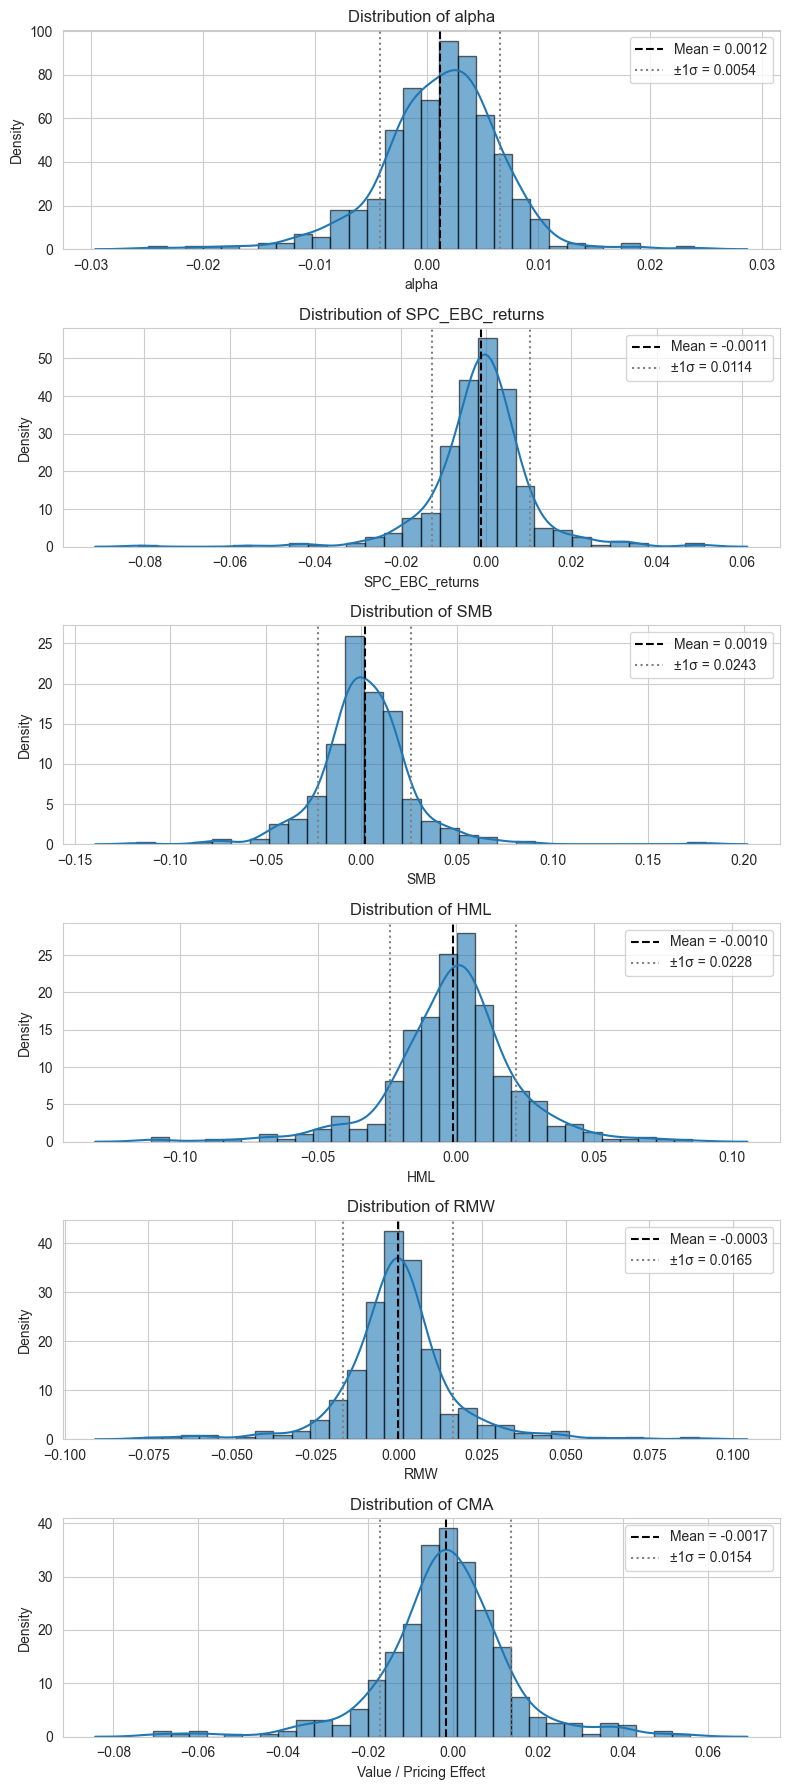

In [50]:
import matplotlib.pyplot as plt

# combine alpha + lambdas into a dictionary
distributions = {'alpha': alphas}
distributions.update({col: lambdas[col] for col in lambdas.columns})

n = len(distributions)
fig, axes = plt.subplots(n, 1, figsize=(8, 3*n), sharex=False)

for i, (name, series) in enumerate(distributions.items()):
    ax = axes[i]
    data = series.dropna()

    # histogram + density line
    ax.hist(data, bins=30, density=True, alpha=0.6, color='tab:blue', edgecolor='black')
    sns.kdeplot(data, ax=ax, color='tab:blue')

    # mean + 1 std lines
    mean = data.mean()
    std = data.std()
    ax.axvline(mean, color='black', linestyle='--', label=f"Mean = {mean:.4f}")
    ax.axvline(mean + std, color='gray', linestyle=':', label=f"±1σ = {std:.4f}")
    ax.axvline(mean - std, color='gray', linestyle=':')

    ax.set_title(f"Distribution of {name}")
    ax.set_ylabel("Density")
    ax.legend()

plt.xlabel("Value / Pricing Effect")
plt.tight_layout()
plt.show()
